# Casino Game Revenue Prediction

## Data Science Module 1 Capstone

**Track:** B — Prediction Lab  
**Project Type:** Regression  
**Dataset:** Synthetic casino gaming data

In [5]:
PROJECT_CONFIG = {
    "track": "B",
    "title": "Casino Game Revenue Prediction",
    "stakeholder": "Casino gaming operations management",
    "decision_question": "Can machine, game, and location characteristics be used to predict monthly gaming revenue?",
    "dataset_source": "Synthetic casino gaming dataset created for educational capstone analysis",
    "row_grain": "One row represents one gaming machine at one location for one month",
    "target_column": "monthly_revenue",
    "id_columns": ["machine_id", "location_id"],
    "seed": 42,
    "test_size": 0.20,
}

SUCCESS_CRITERION = (
    "The predictive model should outperform a simple baseline model "
    "on unseen test data using regression metrics such as MAE, RMSE, and R-squared."
)

PROJECT_CONFIG

{'track': 'B',
 'title': 'Casino Game Revenue Prediction',
 'stakeholder': 'Casino gaming operations management',
 'decision_question': 'Can machine, game, and location characteristics be used to predict monthly gaming revenue?',
 'dataset_source': 'Synthetic casino gaming dataset created for educational capstone analysis',
 'row_grain': 'One row represents one gaming machine at one location for one month',
 'target_column': 'monthly_revenue',
 'id_columns': ['machine_id', 'location_id'],
 'seed': 42,
 'test_size': 0.2}

## 1. Problem and Project Design

### Project Question
Can machine, game, and location characteristics be used to predict monthly gaming revenue?

### Stakeholder
The intended stakeholder is casino gaming operations management. The results could help management better understand which machine, game, and location characteristics are associated with monthly revenue.

### Dataset Relevance
This project uses a synthetic casino gaming dataset created for educational purposes. The dataset contains information about gaming machines, locations, game types, operational activity, betting behavior, and monthly revenue.

### Unit of Analysis
Each row represents one gaming machine at one location for one month.

### Baseline
The project will first use a simple baseline prediction as a reference point. Machine-learning models will then be compared against the baseline to determine whether they provide better predictions.

### Useful Result
A useful result would be a model that predicts monthly revenue more accurately than the baseline on unseen test data. The model does not need to be perfect, but it should show measurable improvement using regression metrics.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = PROJECT_CONFIG["seed"]

print("Libraries imported successfully.")
print("Random seed:", SEED)

Libraries imported successfully.
Random seed: 42


## 2. Dataset and Provenance

This project uses a synthetic casino gaming dataset created specifically for educational data science analysis. The dataset does not contain real casino, customer, or financial records.

The dataset contains monthly operational information for gaming machines across multiple fictional store locations. Each row represents one gaming machine at one location for one month.

The revised dataset includes both a unique `location_id` and a fictional `store_name` to make location-level analysis easier to interpret.

In [7]:
DATA_PATH = "casino_game_revenue_revised_with_store_names.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (2000, 16)


In [8]:
df.head()

,machine_id,location_id,store_name,month,game_type,location_type,distance_from_hq_miles,days_active,avg_bet,payout_rate,total_in,total_out,total_net,number_of_services,machine_swapouts,monthly_revenue
0,M0017,L040,Eagle Ridge Gaming,2025-06-01,Classic Reels,Gaming Hall,13.9,27,1.49,0.897,1877.52,1689.65,187.87,2,1,-400.18
1,M0140,L003,Lone Star Game Center,2026-04-01,A-Liner,Convenience Store,57.5,30,1.74,0.948,1200.00,1145.11,54.89,1,0,362.46
2,M0118,L018,Copper Creek Gaming,2025-01-01,Life of Luxury,Restaurant,18.0,21,2.24,0.915,3833.53,3388.67,444.86,1,0,-206.00
3,M0079,L021,Cedar Grove Gaming,2025-09-01,Classic Reels,Gaming Hall,50.0,26,1.20,0.858,2241.71,1876.70,365.01,0,0,87.87
4,M0078,L036,Greenfield Game Center,2026-03-01,Pot of Gold,Gaming Hall,32.5,23,2.45,NaN,7874.12,6880.70,993.42,0,0,951.83


In [9]:
df.columns.tolist()

['machine_id',
 'location_id',
 'store_name',
 'month',
 'game_type',
 'location_type',
 'distance_from_hq_miles',
 'days_active',
 'avg_bet',
 'payout_rate',
 'total_in',
 'total_out',
 'total_net',
 'number_of_services',
 'machine_swapouts',
 'monthly_revenue']

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   machine_id              2000 non-null   str    
 1   location_id             2000 non-null   str    
 2   store_name              2000 non-null   str    
 3   month                   2000 non-null   str    
 4   game_type               2000 non-null   str    
 5   location_type           2000 non-null   str    
 6   distance_from_hq_miles  1990 non-null   float64
 7   days_active             2000 non-null   int64  
 8   avg_bet                 1986 non-null   float64
 9   payout_rate             1988 non-null   float64
 10  total_in                2000 non-null   float64
 11  total_out               2000 non-null   float64
 12  total_net               2000 non-null   float64
 13  number_of_services      2000 non-null   int64  
 14  machine_swapouts        2000 non-null   int64  
 15

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   machine_id              2000 non-null   str    
 1   location_id             2000 non-null   str    
 2   store_name              2000 non-null   str    
 3   month                   2000 non-null   str    
 4   game_type               2000 non-null   str    
 5   location_type           2000 non-null   str    
 6   distance_from_hq_miles  1990 non-null   float64
 7   days_active             2000 non-null   int64  
 8   avg_bet                 1986 non-null   float64
 9   payout_rate             1988 non-null   float64
 10  total_in                2000 non-null   float64
 11  total_out               2000 non-null   float64
 12  total_net               2000 non-null   float64
 13  number_of_services      2000 non-null   int64  
 14  machine_swapouts        2000 non-null   int64  
 15

In [12]:
df.isnull().sum()

machine_id                 0
location_id                0
store_name                 0
month                      0
game_type                  0
location_type              0
distance_from_hq_miles    10
days_active                0
avg_bet                   14
payout_rate               12
total_in                   0
total_out                  0
total_net                  0
number_of_services         0
machine_swapouts           0
monthly_revenue            0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,distance_from_hq_miles,days_active,avg_bet,payout_rate,total_in,total_out,total_net,number_of_services,machine_swapouts,monthly_revenue
count,1990.000000,2000.000000,1986.000000,1988.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,56.913518,25.524000,1.648459,0.910109,2463.218345,2243.627275,219.591070,0.758000,0.138500,46.593690
std,37.993645,3.462574,0.544535,0.024683,1481.670733,1354.796362,151.865676,0.907109,0.362469,593.981576
min,2.000000,20.000000,0.250000,0.824000,1200.000000,1000.930000,20.810000,0.000000,0.000000,-900.000000
25%,28.225000,22.000000,1.280000,0.893000,1341.440000,1226.165000,120.127500,0.000000,0.000000,-398.417500
50%,48.700000,26.000000,1.640000,0.910000,2040.800000,1841.435000,173.840000,1.000000,0.000000,40.655000
75%,77.175000,29.000000,2.010000,0.927000,2994.225000,2717.267500,270.295000,1.000000,0.000000,461.227500
max,180.000000,31.000000,3.360000,0.970000,13338.130000,12075.380000,1487.660000,6.000000,2.000000,2377.520000


In [15]:
df["monthly_revenue"].describe()

count    2000.000000
mean       46.593690
std       593.981576
min      -900.000000
25%      -398.417500
50%        40.655000
75%       461.227500
max      2377.520000
Name: monthly_revenue, dtype: float64

In [18]:
df.duplicated(subset=["machine_id", "location_id", "month"]).sum()

np.int64(9)

In [19]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
})

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent
distance_from_hq_miles,10,0.5
avg_bet,14,0.7
payout_rate,12,0.6


In [21]:
duplicate_keys = df[
    df.duplicated(
        subset=["machine_id", "location_id", "month"],
        keep=False
    )
].sort_values(
    ["machine_id", "location_id", "month"]
)

duplicate_keys

,machine_id,location_id,store_name,month,game_type,location_type,distance_from_hq_miles,days_active,avg_bet,payout_rate,total_in,total_out,total_net,number_of_services,machine_swapouts,monthly_revenue
844,M0001,L021,Cedar Grove Gaming,2026-02-01,Video Poker,Bar,53.3,24,1.67,0.922,2261.06,2085.75,175.31,2,0,-455.29
845,M0001,L021,Cedar Grove Gaming,2026-02-01,Fire Link,Truck Stop,62.6,25,2.36,0.916,3980.56,3686.27,294.29,0,0,-309.12
1069,M0002,L004,Katy Oaks Gaming,2026-06-01,Life of Luxury,Gaming Hall,28.9,22,1.26,0.892,1529.63,1351.29,178.34,0,0,-47.24
1531,M0002,L004,Katy Oaks Gaming,2026-06-01,Life of Luxury,Truck Stop,37.4,24,1.19,0.931,1766.29,1653.73,112.56,1,0,-51.89
146,M0007,L008,Silver Creek Gaming,2025-08-01,Classic Reels,Truck Stop,NaN,23,1.51,0.879,1345.94,1170.57,175.37,0,0,-747.46
327,M0007,L008,Silver Creek Gaming,2025-08-01,Classic Reels,Truck Stop,19.1,20,1.65,0.933,1200.00,1103.11,96.89,1,0,-133.49
1095,M0015,L034,Highland Park Gaming,2025-04-01,Life of Luxury,Bar,73.4,30,0.55,0.891,1200.00,1076.55,123.45,0,0,107.53
1850,M0015,L034,Highland Park Gaming,2025-04-01,Life of Luxury,Truck Stop,3.5,21,1.24,0.939,1598.52,1484.90,113.62,2,0,-167.02
1636,M0030,L025,Parkside Game Center,2025-05-01,Life of Luxury,Gaming Hall,67.6,25,1.18,0.879,1200.00,1067.12,132.88,0,0,168.09
1940,M0030,L025,Parkside Game Center,2025-05-01,Classic Reels,Restaurant,43.0,21,2.69,0.920,1995.62,1828.84,166.78,2,1,-900.00


In [22]:
duplicate_key_counts = (
    df.groupby(["machine_id", "location_id", "month"])
      .size()
      .reset_index(name="row_count")
)

duplicate_key_counts[
    duplicate_key_counts["row_count"] > 1
]

,machine_id,location_id,month,row_count
8,M0001,L021,2026-02-01,2
15,M0002,L004,2026-06-01,2
66,M0007,L008,2025-08-01,2
148,M0015,L034,2025-04-01,2
348,M0030,L025,2025-05-01,2
374,M0033,L004,2025-02-01,2
801,M0075,L008,2025-04-01,2
861,M0080,L016,2025-08-01,2
1297,M0118,L030,2025-01-01,2


### Duplicate and Record-Grain Validation

The dataset contains no exact duplicate rows. However, 9 combinations of `machine_id`, `location_id`, and `month` occur more than once.

Inspection showed that these repeated combinations are not identical records. Several contain different operational characteristics, such as game type, location type, or distance from headquarters. Therefore, these records were retained rather than automatically removed.

This check shows that `machine_id`, `location_id`, and `month` do not form a guaranteed unique key in the synthetic dataset. For this analysis, each row is treated as an individual monthly gaming-machine observation.

In [23]:
columns_to_impute = [
    "distance_from_hq_miles",
    "avg_bet",
    "payout_rate"
]

for column in columns_to_impute:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after cleaning:")
print(df[columns_to_impute].isnull().sum())

Missing values after cleaning:
distance_from_hq_miles    0
avg_bet                   0
payout_rate               0
dtype: int64


### Missing-Value Treatment

Missing values were identified in `distance_from_hq_miles`, `avg_bet`, and `payout_rate`. Each affected column had less than 1% missing data.

The missing numeric values were replaced with the median of their respective columns. Median imputation was selected because it preserves all 2,000 observations and is less sensitive to unusually high or low values than mean imputation.

After imputation, a validation check confirmed that all three columns contained zero missing values.

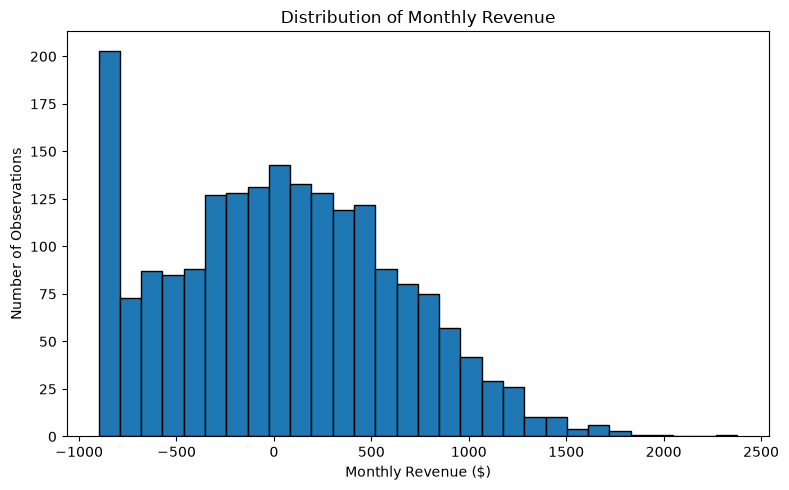

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(df["monthly_revenue"], bins=30, edgecolor="black")

plt.title("Distribution of Monthly Revenue")
plt.xlabel("Monthly Revenue ($)")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

### Monthly Revenue Distribution

Monthly revenue varies substantially across the synthetic gaming-machine observations, including both negative and positive values. Most observations are concentrated around the lower and middle revenue ranges, while a smaller number extend to much higher positive revenue values.

The distribution shows a noticeable right tail, indicating that some machine-month observations generate substantially higher revenue than most others. This variability is important because `monthly_revenue` is the regression target the predictive models will attempt to estimate.

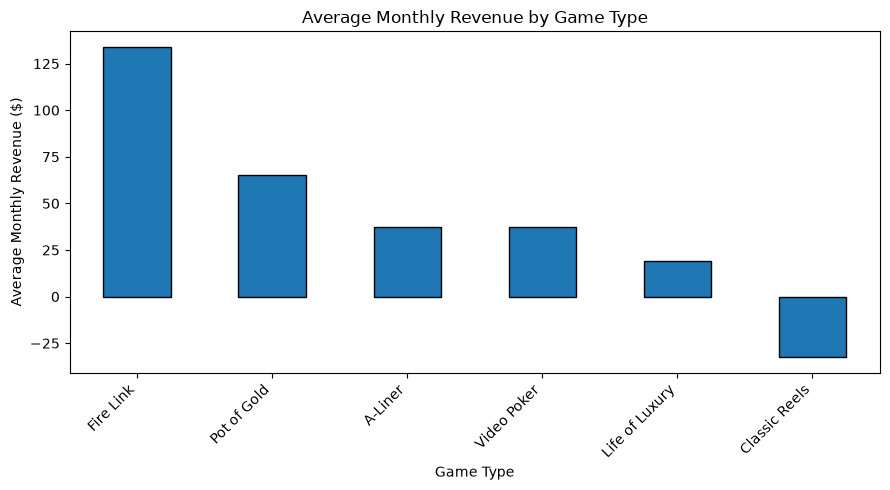

In [25]:
game_revenue = (
    df.groupby("game_type")["monthly_revenue"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

game_revenue.plot(kind="bar", edgecolor="black")

plt.title("Average Monthly Revenue by Game Type")
plt.xlabel("Game Type")
plt.ylabel("Average Monthly Revenue ($)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Revenue by Game Type

Average monthly revenue differs across game types in the synthetic dataset. Fire Link has the highest average monthly revenue, while Classic Reels has a negative average monthly revenue. The remaining game types fall between these two values.

These differences suggest that game type may contain useful predictive information for the regression model. However, this visualization shows an association only and does not demonstrate that game type causes the differences in revenue, because other machine, location, and operational characteristics may also contribute.

In [26]:
numeric_columns = df.select_dtypes(include=["number"])

revenue_correlations = (
    numeric_columns.corr()["monthly_revenue"]
    .sort_values(ascending=False)
)

revenue_correlations

monthly_revenue           1.000000
days_active               0.647886
total_net                 0.393128
total_in                  0.381578
total_out                 0.373244
avg_bet                   0.146718
distance_from_hq_miles   -0.059211
payout_rate              -0.101143
machine_swapouts         -0.226441
number_of_services       -0.337783
Name: monthly_revenue, dtype: float64

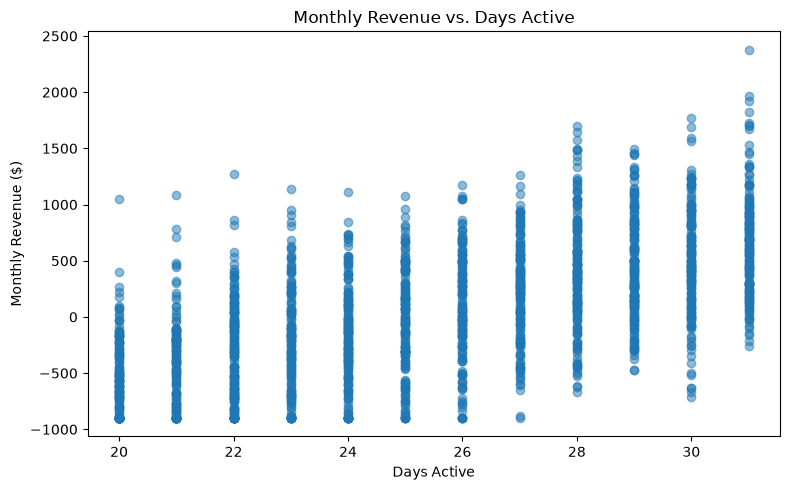

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["days_active"],
    df["monthly_revenue"],
    alpha=0.5
)

plt.title("Monthly Revenue vs. Days Active")
plt.xlabel("Days Active")
plt.ylabel("Monthly Revenue ($)")

plt.tight_layout()
plt.show()

### Monthly Revenue and Days Active

The scatter plot shows a positive relationship between `days_active` and `monthly_revenue`. As the number of active days increases, monthly revenue generally tends to increase.

However, there is substantial variation in revenue at each number of active days. This indicates that days active is an important predictor, but it does not explain monthly revenue by itself. Other game, machine, location, and operational characteristics are also likely contributing to revenue differences.

## 4. Predictive Modeling

The goal of the modeling stage is to predict `monthly_revenue` using machine, game, location, and operational characteristics.

A simple baseline model will be evaluated first. More advanced regression models will then be compared against this baseline using the same train/test split and evaluation metrics.

In [28]:
y = df["monthly_revenue"]

print("Target variable:", y.name)
print("Number of observations:", len(y))

Target variable: monthly_revenue
Number of observations: 2000


In [29]:
features = [
    "game_type",
    "location_type",
    "distance_from_hq_miles",
    "days_active",
    "avg_bet",
    "payout_rate",
    "total_in",
    "total_out",
    "number_of_services",
    "machine_swapouts"
]

X = df[features].copy()

print("Number of predictor columns:", X.shape[1])
print("Predictor columns:")
print(X.columns.tolist())

Number of predictor columns: 10
Predictor columns:
['game_type', 'location_type', 'distance_from_hq_miles', 'days_active', 'avg_bet', 'payout_rate', 'total_in', 'total_out', 'number_of_services', 'machine_swapouts']


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=PROJECT_CONFIG["test_size"],
    random_state=SEED
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 1600
Testing observations: 400


In [31]:
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(
    np.zeros((len(X_train), 1)),
    y_train
)

baseline_predictions = baseline_model.predict(
    np.zeros((len(X_test), 1))
)

print("Baseline prediction:", round(baseline_predictions[0], 2))

Baseline prediction: 44.46


In [32]:
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R-squared:", round(baseline_r2, 4))

Baseline MAE: 441.34
Baseline RMSE: 549.06
Baseline R-squared: -0.0004


In [33]:
categorical_columns = ["game_type", "location_type"]

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    drop_first=True
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Original predictor columns:", X_train.shape[1])
print("Encoded training columns:", X_train_encoded.shape[1])
print("Encoded testing columns:", X_test_encoded.shape[1])

Original predictor columns: 10
Encoded training columns: 17
Encoded testing columns: 17


In [34]:
linear_model = LinearRegression()

linear_model.fit(X_train_encoded, y_train)

linear_predictions = linear_model.predict(X_test_encoded)

print("Linear Regression trained successfully.")
print("Number of predictions:", len(linear_predictions))
print("First 5 predictions:", np.round(linear_predictions[:5], 2))

Linear Regression trained successfully.
Number of predictions: 400
First 5 predictions: [-195.92 -333.62   -1.1  -400.74  614.41]


In [35]:
linear_model.predict(X_test_encoded)

array([-1.95916111e+02, -3.33622407e+02, -1.09717447e+00, -4.00735456e+02,
        6.14413640e+02,  7.60971606e+02,  5.60125714e+02, -2.87530231e+02,
       -1.66348742e+02,  1.25724056e+02, -4.98554309e+02,  1.36422672e+02,
        5.60094844e+02, -5.58448404e+02,  6.43124967e+02, -7.01888191e+02,
        5.92552290e+02,  3.40387715e+02, -5.71902889e+02, -4.51423652e+01,
       -5.76037803e+01, -4.51892022e+02,  6.28646225e+01,  2.01493035e+01,
       -3.47020524e+02,  6.16872297e+02,  1.21597086e+02,  4.61617694e+02,
        2.77364838e+01,  5.83491166e+02, -2.81031510e+02, -3.35193459e+02,
       -2.36025895e+02,  4.03165800e+02,  5.63161739e+02,  3.56248791e+02,
       -7.14504997e+01,  1.75801508e+02,  5.82448952e+01,  4.05345860e+02,
       -9.14800786e+01,  3.48189026e+02, -1.68758826e+02,  4.22401779e+02,
        5.16359174e+02,  8.41676784e+01,  6.15798018e+02, -3.48771570e+02,
       -1.22618330e+03,  4.90859581e+02,  3.72198223e+02, -1.47994392e+02,
        2.17422789e+01, -

In [36]:
print("Linear Regression trained successfully.")
print("Number of predictions:", len(linear_predictions))
print("First 5 predictions:", np.round(linear_predictions[:5], 2))

Linear Regression trained successfully.
Number of predictions: 400
First 5 predictions: [-195.92 -333.62   -1.1  -400.74  614.41]


In [37]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression MAE:", round(linear_mae, 2))
print("Linear Regression RMSE:", round(linear_rmse, 2))
print("Linear Regression R-squared:", round(linear_r2, 4))

Linear Regression MAE: 304.91
Linear Regression RMSE: 380.57
Linear Regression R-squared: 0.5194


In [38]:
mae_improvement = (
    (baseline_mae - linear_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - linear_rmse) / baseline_rmse
) * 100

print("MAE improvement over baseline:", round(mae_improvement, 2), "%")
print("RMSE improvement over baseline:", round(rmse_improvement, 2), "%")

MAE improvement over baseline: 30.91 %
RMSE improvement over baseline: 30.69 %


In [39]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=SEED
)

random_forest_model.fit(X_train_encoded, y_train)

rf_predictions = random_forest_model.predict(X_test_encoded)

print("Random Forest trained successfully.")
print("Number of predictions:", len(rf_predictions))
print("First 5 predictions:", np.round(rf_predictions[:5], 2))

Random Forest trained successfully.
Number of predictions: 400
First 5 predictions: [-152.72 -104.71  -75.11 -452.57  601.22]


In [40]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest R-squared:", round(rf_r2, 4))

Random Forest MAE: 326.8
Random Forest RMSE: 410.89
Random Forest R-squared: 0.4398


In [41]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R_squared": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

model_results.round(2)

,Model,MAE,RMSE,R_squared
0,Baseline,441.34,549.06,-0.00
1,Linear Regression,304.91,380.57,0.52
2,Random Forest,326.80,410.89,0.44


In [44]:
features_without_total_net = [
    feature for feature in features
    if feature != "total_net"
]

X_no_net = df[features_without_total_net].copy()

print("Original number of predictors:", len(features))
print("Predictors without total_net:", len(features_without_total_net))
print(features_without_total_net)

Original number of predictors: 10
Predictors without total_net: 10
['game_type', 'location_type', 'distance_from_hq_miles', 'days_active', 'avg_bet', 'payout_rate', 'total_in', 'total_out', 'number_of_services', 'machine_swapouts']


In [45]:
X_train_no_net, X_test_no_net, y_train_no_net, y_test_no_net = train_test_split(
    X_no_net,
    y,
    test_size=PROJECT_CONFIG["test_size"],
    random_state=SEED
)

print("Training observations:", len(X_train_no_net))
print("Testing observations:", len(X_test_no_net))

Training observations: 1600
Testing observations: 400


In [46]:
categorical_columns = ["game_type", "location_type"]

X_train_no_net_encoded = pd.get_dummies(
    X_train_no_net,
    columns=categorical_columns,
    drop_first=True
)

X_test_no_net_encoded = pd.get_dummies(
    X_test_no_net,
    columns=categorical_columns,
    drop_first=True
)

X_test_no_net_encoded = X_test_no_net_encoded.reindex(
    columns=X_train_no_net_encoded.columns,
    fill_value=0
)

print("Before encoding:", X_train_no_net.shape[1])
print("After encoding - training:", X_train_no_net_encoded.shape[1])
print("After encoding - testing:", X_test_no_net_encoded.shape[1])

Before encoding: 10
After encoding - training: 17
After encoding - testing: 17


In [47]:
linear_model_no_net = LinearRegression()

linear_model_no_net.fit(
    X_train_no_net_encoded,
    y_train_no_net
)

linear_predictions_no_net = linear_model_no_net.predict(
    X_test_no_net_encoded
)

print("Linear Regression without total_net trained successfully.")
print("Number of predictions:", len(linear_predictions_no_net))
print("First 5 predictions:", np.round(linear_predictions_no_net[:5], 2))

Linear Regression without total_net trained successfully.
Number of predictions: 400
First 5 predictions: [-195.92 -333.62   -1.1  -400.74  614.41]


In [48]:
linear_no_net_mae = mean_absolute_error(
    y_test_no_net,
    linear_predictions_no_net
)

linear_no_net_rmse = np.sqrt(
    mean_squared_error(
        y_test_no_net,
        linear_predictions_no_net
    )
)

linear_no_net_r2 = r2_score(
    y_test_no_net,
    linear_predictions_no_net
)

print("Without total_net MAE:", round(linear_no_net_mae, 2))
print("Without total_net RMSE:", round(linear_no_net_rmse, 2))
print("Without total_net R-squared:", round(linear_no_net_r2, 4))

Without total_net MAE: 304.91
Without total_net RMSE: 380.57
Without total_net R-squared: 0.5194


In [49]:
print("Original features:")
print(features)

print("\nIs total_net included?")
print("total_net" in features)

Original features:
['game_type', 'location_type', 'distance_from_hq_miles', 'days_active', 'avg_bet', 'payout_rate', 'total_in', 'total_out', 'number_of_services', 'machine_swapouts']

Is total_net included?
False
